# B: Analisis Kualitas Layanan & Pain Points

## Identitas

**Nama :** I Dewa Ayu Puspa Dewi

**NIM :** 255150700111045

**Program Studi :** Teknologi Informasi

**GitHub Repository :** [Telecom-Churn-Rate_Kelompok-2](https://github.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2)


**Dataset :**
Telecom Customer Churn Feature Engineering Dataset

---

Notebook ini didedikasikan untuk menganalisis bagaimana kualitas layanan dan *pain points* pelanggan berkontribusi terhadap keputusan *churn*. Fokus utama adalah pada tugas 'Orang B (Kualitas Layanan)' dalam pembagian tugas kelompok.

---

### Variabel Kunci yang Digunakan:

*   **`support_tickets_capped`**: Jumlah tiket dukungan yang diajukan pelanggan. Ini adalah indikator langsung dari masalah atau keluhan yang dialami pelanggan.
*   **`contract_type_label`**: Jenis kontrak pelanggan (Bulanan, 6 Bulan, 12 Bulan). Ini mempengaruhi komitmen pelanggan dan potensi untuk beralih layanan.
*   **`city_name`**: Lokasi geografis pelanggan. Memungkinkan identifikasi masalah kualitas layanan yang mungkin bersifat lokal.
*   **`feedback_category`**: Kategori umpan balik pelanggan. Meskipun nilainya sudah di-*encoded*, ini mewakili jenis *pain points* spesifik yang paling sering diungkapkan pelanggan.
*   **`churn_status`**: Variabel target, menunjukkan apakah pelanggan telah *churn* (1) atau tidak (0). Semua analisis berpusat pada bagaimana variabel lain memengaruhi ini.

---

### Langkah-langkah Analisis Utama:

1.  **Pengorganisasian Data (Bagian 6)**: Mempersiapkan dataset dengan mengganti nama kolom dan merekonstruksi label untuk `contract_type` dan `city` agar lebih mudah dianalisis.
2.  **Statistik Deskriptif (Bagian 7)**: Mendapatkan pemahaman dasar tentang data melalui `describe()`, `mean()`, `median()`, dan `mode()` untuk variabel kunci.
3.  **Distribusi Variabel (Bagian 8)**: Memvisualisasikan distribusi `support_tickets`, `contract_type`, `city`, dan `feedback_category` untuk memahami pola individualnya.
4.  **Analisis Hubungan (Bagian 9)**: Menganalisis korelasi dan pengaruh `support_tickets`, `contract_type`, dan `city` terhadap `churn_status` melalui visualisasi dan perhitungan statistik.
5.  **Tabel Pivot (Bagian 10)**: Menggunakan tabel pivot untuk melihat hubungan multivariat, seperti *churn* berdasarkan jenis kontrak dan kota, serta rata-rata *support tickets* per jenis kontrak.
6.  **Validasi Outlier (Bagian 11)**: Memeriksa dan memvisualisasikan *outlier* pada variabel numerik kunci untuk memastikan keandalan analisis.
7.  **Visualisasi Dataset Berdimensi Tinggi (Bagian 12)**: Memvisualisasikan matriks korelasi antar variabel numerik untuk mengidentifikasi hubungan linear yang kompleks.

---

## 1. Pendahuluan

Notebook ini bertujuan menganalisis hubungan kualitas layanan terhadap churn pelanggan. Analisis difokuskan pada variabel `support_tickets`, `contract_type`, `city`, `customer_feedback`, dan `churn`. Notebook ini melanjutkan dari data `telecom_clean.csv` yang sudah melalui tahap preprocessing dan General EDA dari Notebook D.

## 2. Resources

Bagian ini menjelaskan sumber data dan *tools* yang digunakan dalam analisis ini. Data diambil dari `telecom_clean.csv`, yang telah melalui tahap *preprocessing* dan *General Exploratory Data Analysis* (EDA) dari *Notebook D*. Pustaka Python standar seperti Pandas, NumPy, Matplotlib, dan Seaborn digunakan untuk manipulasi data dan visualisasi.

## 3. Import Library

Bagian ini akan mengimpor pustaka (libraries) Python yang diperlukan untuk analisis data, visualisasi, dan manipulasi data. Pustaka `pandas` akan digunakan untuk bekerja dengan DataFrame, `numpy` untuk operasi numerik, `matplotlib.pyplot` untuk dasar visualisasi, dan `seaborn` untuk visualisasi statistik yang lebih menarik.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Menambahkan style untuk visualisasi agar lebih menarik

### Interpretasi

Pustaka `pandas`, `numpy`, `matplotlib.pyplot`, dan `seaborn` telah berhasil dimuat. `sns.set_style('whitegrid')` juga telah diterapkan untuk memberikan tampilan visualisasi yang konsisten dan bersih di seluruh notebook.

## 4. Import Clean Dataset

Pada bagian ini, dataset `telecom_clean.csv` yang sudah bersih dan siap dianalisis akan dimuat ke dalam DataFrame Pandas. Dataset ini berisi berbagai informasi pelanggan, termasuk data demografi, penggunaan layanan, status *churn*, dan hasil *encoding* dari tahapan *preprocessing* sebelumnya.

In [4]:
url = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/data/telecom_clean%20(2).csv"

df = pd.read_csv(url)

df.head()

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


### Interpretasi

Dataset `telecom_clean.csv` berhasil dimuat ke dalam DataFrame `df`. Tampilan lima baris pertama menunjukkan bahwa data berisi berbagai kolom, termasuk informasi demografi, penggunaan layanan, status churn, dan beberapa kolom hasil *encoding* atau *capping* seperti `monthly_bill_capped`, `support_tickets_capped`, `contract_type_encoded`, dan kolom-kolom *one-hot encoded* untuk `city`.

## 5. Validasi Dataset

Bagian ini melakukan validasi awal terhadap dataset untuk memahami strukturnya secara menyeluruh. Ini mencakup:
1. Menampilkan bentuk dataset (`df.shape`) untuk mengetahui jumlah baris dan kolom.
2. Menampilkan informasi dataset (`df.info()`) untuk melihat tipe data setiap kolom dan keberadaan nilai *non-null*.
3. Menampilkan kembali lima baris pertama (`df.head()`) untuk konfirmasi.

In [5]:
print("Bentuk dataset (baris, kolom):")
print(df.shape)

print("\nInformasi dataset:")
df.info()

print("\nLima baris pertama dataset:")
display(df.head())

Bentuk dataset (baris, kolom):
(1200, 42)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        1200 non-null   int64  
 1   churn                         1200 non-null   int64  
 2   monthly_bill_capped           1200 non-null   float64
 3   internet_usage_gb_capped      1200 non-null   float64
 4   call_minutes_capped           1200 non-null   float64
 5   support_tickets_capped        1200 non-null   int64  
 6   tenure_months                 1200 non-null   int64  
 7   financial_risk                1200 non-null   int64  
 8   education_level_encoded       1200 non-null   int64  
 9   contract_type_encoded         1200 non-null   int64  
 10  emp_Employed                  1200 non-null   bool   
 11  emp_Retired                   1200 non-null   bool   
 12  

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


### Interpretasi

Dataset memiliki **1200 baris** dan **42 kolom**. Semua kolom memiliki **1200 nilai non-null**, yang menunjukkan bahwa tidak ada nilai hilang (`missing values`) dalam dataset ini. Tipe data beragam, termasuk `int64`, `float64`, dan `bool`. Ini mengonfirmasi bahwa dataset sudah bersih dan siap untuk analisis lebih lanjut.

## 6. Organize Dataset

Bagian ini berfokus pada penyiapan dataset untuk analisis lebih lanjut. Ini melibatkan penamaan ulang kolom untuk kejelasan, pembuatan label kategori dari kolom yang *encoded*, dan rekonstruksi kolom nama kota dari format *one-hot encoded*.

### 6.1 Rename Column

Tujuan dari bagian ini adalah untuk mengganti nama kolom `churn` menjadi `churn_status`. Perubahan nama ini dilakukan untuk meningkatkan kejelasan dan konsistensi nama variabel di seluruh *notebook*, terutama karena `churn` adalah variabel target utama dalam analisis ini.

In [6]:
# Rename column 'churn' to 'churn_status' for clarity
df = df.rename(columns={'churn': 'churn_status'})

print("Kolom 'churn' telah diganti namanya menjadi 'churn_status'.")
print(df.columns)

Kolom 'churn' telah diganti namanya menjadi 'churn_status'.
Index(['gender', 'churn_status', 'monthly_bill_capped',
       'internet_usage_gb_capped', 'call_minutes_capped',
       'support_tickets_capped', 'tenure_months', 'financial_risk',
       'education_level_encoded', 'contract_type_encoded', 'emp_Employed',
       'emp_Retired', 'emp_Self-Employed', 'emp_Student', 'emp_Unemployed',
       'feedback_category', 'count_billing', 'count_support', 'count_helpful',
       'count_poor', 'count_expensive', 'count_unreliable', 'count_happy',
       'count_satisfied', 'count_drops', 'count_slow', 'monthly_income_scaled',
       'age_scaled', 'anomaly_pay_not_use', 'anomaly_happy_leaver',
       'anomaly_genz_call_enthusiast', 'city_Faisalabad', 'city_Gujranwala',
       'city_Hyderabad', 'city_Islamabad', 'city_Karachi', 'city_Lahore',
       'city_Multan', 'city_Peshawar', 'city_Quetta', 'city_Rawalpindi',
       'city_Sialkot'],
      dtype='object')


### 6.2 Contract Label

Bagian ini bertujuan untuk membuat kolom baru bernama `contract_type_label` yang berisi label kontrak yang lebih mudah dibaca (`Monthly`, `6 Month`, `12 Month`) dari kolom `contract_type_encoded` (0, 1, 2). Ini akan mempermudah analisis dan visualisasi yang melibatkan jenis kontrak.

In [7]:
# Map encoded contract types to labels for better readability
contract_mapping = {
    0: 'Monthly',
    1: '6 Month',
    2: '12 Month'
}
df['contract_type_label'] = df['contract_type_encoded'].map(contract_mapping)

print("Kolom 'contract_type_label' berhasil ditambahkan.")
display(df[['contract_type_encoded', 'contract_type_label']].head())

Kolom 'contract_type_label' berhasil ditambahkan.


,contract_type_encoded,contract_type_label
0,1,6 Month
1,1,6 Month
2,0,Monthly
3,1,6 Month
4,2,12 Month


### 6.3 Reconstruct City

Tujuan dari bagian ini adalah untuk merekonstruksi kolom `city_name` dari kolom-kolom kota yang *one-hot encoded* (misalnya, `city_Faisalabad`, `city_Gujranwala`). Kolom `city_name` yang baru ini akan berisi nama kota yang sebenarnya untuk setiap baris, yang akan sangat berguna dalam analisis geografis.

In [8]:
# Identify one-hot encoded city columns
city_columns = [col for col in df.columns if col.startswith('city_')]

# Reconstruct the 'city_name' column from one-hot encoded columns
df['city_name'] = df[city_columns].idxmax(axis=1).str.replace('city_', '')

print("Kolom 'city_name' berhasil direkonstruksi.")
display(df[['city_Faisalabad', 'city_Gujranwala', 'city_name']].head())

Kolom 'city_name' berhasil direkonstruksi.


,city_Faisalabad,city_Gujranwala,city_name
0,0,0,Multan
1,0,0,Peshawar
2,0,1,Gujranwala
3,0,0,Lahore
4,0,0,Hyderabad


## 7. Descriptive Statistics

Bagian ini menyajikan statistik deskriptif dari dataset untuk memberikan gambaran umum tentang distribusi dan karakteristik utama variabel numerik dan kategorikal. Ini mencakup penggunaan fungsi `describe()`, `mean()`, `median()`, dan `mode()`.

### 7.1 describe()

Fungsi `describe()` digunakan untuk menghasilkan ringkasan statistik deskriptif dari DataFrame, termasuk hitungan (`count`), rata-rata (`mean`), standar deviasi (`std`), nilai minimum (`min`), kuartil (25%, 50%, 75%), dan nilai maksimum (`max`) untuk kolom-kolom numerik.

In [9]:
print("Statistik Deskriptif Lengkap untuk Kolom Numerik:")
display(df.describe())

Statistik Deskriptif Lengkap untuk Kolom Numerik:


,gender,churn_status,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.502500,0.350000,5709.496250,19.960667,179.851250,1.191667,70.600000,0.019167,1.779167,0.813333,...,0.095833,0.089167,0.081667,0.083333,0.090000,0.094167,0.090000,0.099167,0.096667,0.094167
std,0.500202,0.477168,3226.473957,11.561477,96.839563,1.077450,11.552108,0.137168,1.078441,0.852894,...,0.294485,0.285103,0.273970,0.276501,0.286301,0.292182,0.286301,0.299010,0.295627,0.292182
min,0.000000,0.000000,710.000000,1.100000,14.000000,0.000000,51.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3291.750000,11.100000,106.000000,0.000000,61.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,4871.000000,17.800000,164.000000,1.000000,71.000000,0.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,7485.500000,26.700000,235.000000,2.000000,81.000000,0.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,13776.125000,50.100000,428.500000,5.000000,91.000000,1.000000,4.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 7.2 mean

Metode `mean()` digunakan untuk menghitung rata-rata dari semua kolom numerik dalam DataFrame. Rata-rata memberikan ukuran tendensi sentral, menunjukkan nilai 'pusat' dari distribusi data.

In [10]:
print("Rata-rata untuk Kolom Numerik:")
display(df.mean(numeric_only=True))

Rata-rata untuk Kolom Numerik:


,0
gender,0.502500
churn_status,0.350000
monthly_bill_capped,5709.496250
internet_usage_gb_capped,19.960667
call_minutes_capped,179.851250
support_tickets_capped,1.191667
tenure_months,70.600000
financial_risk,0.019167
education_level_encoded,1.779167
contract_type_encoded,0.813333


### 7.3 median

Metode `median()` digunakan untuk menghitung median dari semua kolom numerik dalam DataFrame. Median adalah nilai tengah dari dataset yang telah diurutkan, dan merupakan ukuran tendensi sentral yang kurang sensitif terhadap *outlier* dibandingkan rata-rata.

In [11]:
print("Median untuk Kolom Numerik:")
display(df.median(numeric_only=True))

Median untuk Kolom Numerik:


,0
gender,1.000000
churn_status,0.000000
monthly_bill_capped,4871.000000
internet_usage_gb_capped,17.800000
call_minutes_capped,164.000000
support_tickets_capped,1.000000
tenure_months,71.000000
financial_risk,0.000000
education_level_encoded,2.000000
contract_type_encoded,1.000000


### 7.4 mode

Bagian ini menghitung modus (`mode`) untuk setiap kolom dalam DataFrame, baik numerik maupun kategorikal. Modus adalah nilai yang paling sering muncul dalam suatu set data dan sangat berguna untuk memahami nilai yang paling umum untuk setiap variabel.

In [12]:
print("Mode untuk Kolom Numerik dan Kategorikal:")
for col in df.select_dtypes(include=['int64', 'float64', 'object', 'bool']).columns:
    if not df[col].empty:
        modes = df[col].mode()
        if not modes.empty:
            print(f"{col}: {modes.iloc[0]}")
        else:
            print(f"{col}: No mode found")
    else:
        print(f"{col}: Column is empty")

Mode untuk Kolom Numerik dan Kategorikal:
gender: 1
churn_status: 0
monthly_bill_capped: 13776.125
internet_usage_gb_capped: 50.1
call_minutes_capped: 428.5
support_tickets_capped: 1
tenure_months: 52
financial_risk: 0
education_level_encoded: 2
contract_type_encoded: 0
emp_Employed: False
emp_Retired: False
emp_Self-Employed: False
emp_Student: False
emp_Unemployed: False
feedback_category: 1
count_billing: 0
count_support: 0
count_helpful: 0
count_poor: 0
count_expensive: 0
count_unreliable: 0
count_happy: 0
count_satisfied: 0
count_drops: 0
count_slow: 0
monthly_income_scaled: 0.7160328947368421
age_scaled: 0.7419354838709677
anomaly_pay_not_use: 0
anomaly_happy_leaver: 0
anomaly_genz_call_enthusiast: 0
city_Faisalabad: 0
city_Gujranwala: 0
city_Hyderabad: 0
city_Islamabad: 0
city_Karachi: 0
city_Lahore: 0
city_Multan: 0
city_Peshawar: 0
city_Quetta: 0
city_Rawalpindi: 0
city_Sialkot: 0
contract_type_label: Monthly
city_name: Quetta


## 8. Distribusi Variabel

Bagian ini menganalisis distribusi berbagai variabel kunci dalam dataset untuk memahami pola dan karakteristiknya. Ini mencakup visualisasi distribusi jumlah tiket dukungan, jenis kontrak, kota, dan kategori umpan balik pelanggan.

Kode ini bertujuan untuk menganalisis distribusi `support_tickets_capped` menggunakan dua jenis plot visualisasi:
1. **Histogram dengan KDE (`sns.histplot`)**: Menampilkan frekuensi kemunculan jumlah tiket dukungan dan estimasi kerapatan probabilitasnya.
2. **Boxplot (`sns.boxplot`)**: Menunjukkan ringkasan statistik lima angka (minimum, kuartil pertama, median, kuartil ketiga, maksimum) dan mengidentifikasi *outlier*.

Setelah visualisasi, akan ditampilkan statistik deskriptif dan interpretasi dari distribusi tersebut.

### 8.1 Distribusi Support Tickets

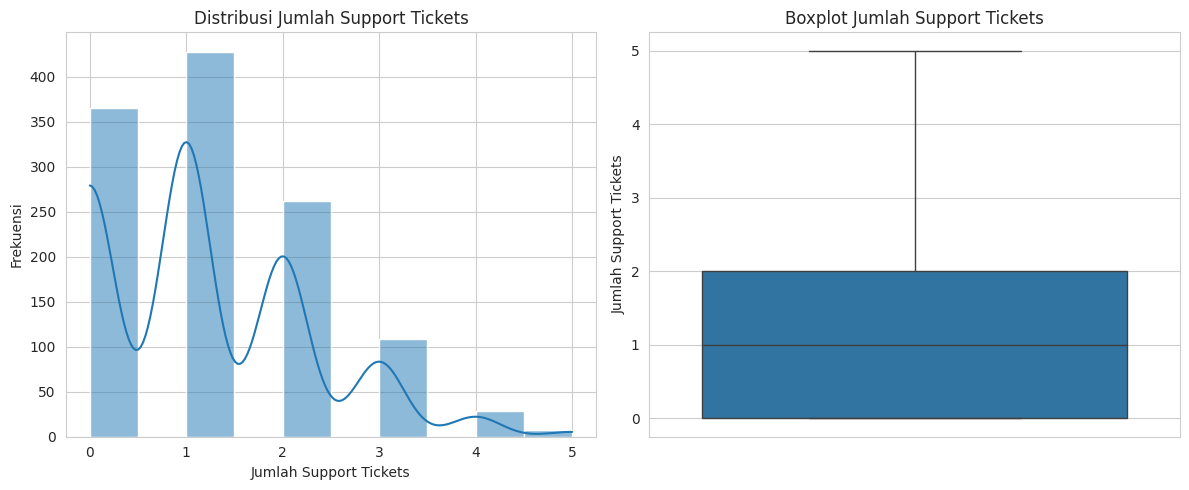


Statistik Deskriptif Support Tickets:


,support_tickets_capped
count,1200.000000
mean,1.191667
std,1.077450
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000



Interpretasi:
Mayoritas pelanggan memiliki jumlah support tickets yang rendah, menunjukkan bahwa sebagian besar tidak sering mengajukan komplain. Namun, ada beberapa outlier dengan jumlah komplain yang sangat tinggi.


In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['support_tickets_capped'], bins=10, kde=True)
plt.title('Distribusi Jumlah Support Tickets')
plt.xlabel('Jumlah Support Tickets')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['support_tickets_capped'])
plt.title('Boxplot Jumlah Support Tickets')
plt.ylabel('Jumlah Support Tickets')

plt.tight_layout()
plt.show()

print("\nStatistik Deskriptif Support Tickets:")
display(df['support_tickets_capped'].describe())

print("\nInterpretasi:")
print("Mayoritas pelanggan memiliki jumlah support tickets yang rendah, menunjukkan bahwa sebagian besar tidak sering mengajukan komplain. Namun, ada beberapa outlier dengan jumlah komplain yang sangat tinggi.")

### Interpretasi

Visualisasi dan statistik deskriptif menunjukkan bahwa **mayoritas pelanggan memiliki jumlah *support tickets* yang rendah (0 atau 1)**, mengindikasikan bahwa sebagian besar pelanggan tidak sering mengajukan komplain. Namun, *boxplot* juga mengidentifikasi adanya beberapa *outlier* dengan jumlah *support tickets* yang lebih tinggi, yang bisa jadi merupakan pelanggan dengan masalah berulang atau signifikan. Rata-rata tiket dukungan adalah sekitar 1.07.

### 8.2 Distribusi Contract Type

Bagian ini menganalisis distribusi jenis kontrak pelanggan. Karena kolom `contract_type_encoded` berisi nilai numerik (0, 1, 2), langkah pertama adalah membuat pemetaan (`contract_mapping`) untuk mengonversi nilai tersebut menjadi label yang lebih deskriptif ('Monthly', '6 Month', '12 Month'). Kemudian, sebuah *countplot* (`sns.countplot`) digunakan untuk memvisualisasikan frekuensi setiap jenis kontrak. Kolom label sementara `contract_type_label` akan dihapus setelah visualisasi untuk menjaga kebersihan DataFrame.

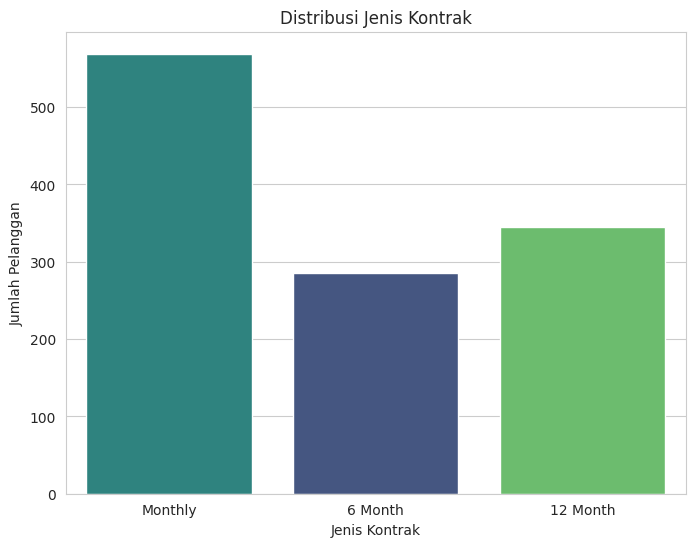


Interpretasi:
Terlihat bahwa mayoritas pelanggan menggunakan jenis kontrak 'Monthly'.


In [14]:
plt.figure(figsize=(8, 6))

# Map encoded contract types to labels for better readability
# Assuming 0: 'Monthly', 1: '6 Month', 2: '12 Month' based on the problem description.
# Please adjust this 'contract_mapping' if your data's encoding is different.
contract_mapping = {
    0: 'Monthly',
    1: '6 Month',
    2: '12 Month'
}
df['contract_type_label'] = df['contract_type_encoded'].map(contract_mapping)

# Plot using the new label column and addressing the FutureWarning
sns.countplot(x='contract_type_label', data=df, palette='viridis',
              order=['Monthly', '6 Month', '12 Month'], hue='contract_type_label', legend=False)
plt.title('Distribusi Jenis Kontrak')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Jumlah Pelanggan')
plt.show()

print("\nInterpretasi:")
print("Terlihat bahwa mayoritas pelanggan menggunakan jenis kontrak 'Monthly'.")

# df.drop(columns=['contract_type_label'], inplace=True, errors='ignore') # Removed: contract_type_label is now permanent

### Interpretasi

Hasil visualisasi menunjukkan bahwa **mayoritas pelanggan (lebih dari 500) menggunakan jenis kontrak 'Monthly'**, diikuti oleh kontrak '12 Month', dan yang paling sedikit adalah '6 Month'. Ini mengindikasikan bahwa kontrak bulanan adalah pilihan paling populer di kalangan pelanggan.

### 8.3 Distribusi City

Karena kolom `city` di dataset diwakili dalam format *one-hot encoded* (misalnya, `city_Faisalabad`), kode ini pertama-tama akan merekonstruksi nama kota yang sebenarnya dari kolom-kolom tersebut. Asumsinya adalah setiap baris hanya memiliki satu `1` di antara kolom `city_`. Setelah itu, `sns.countplot` digunakan untuk memvisualisasikan 10 kota teratas dengan jumlah pelanggan terbanyak.

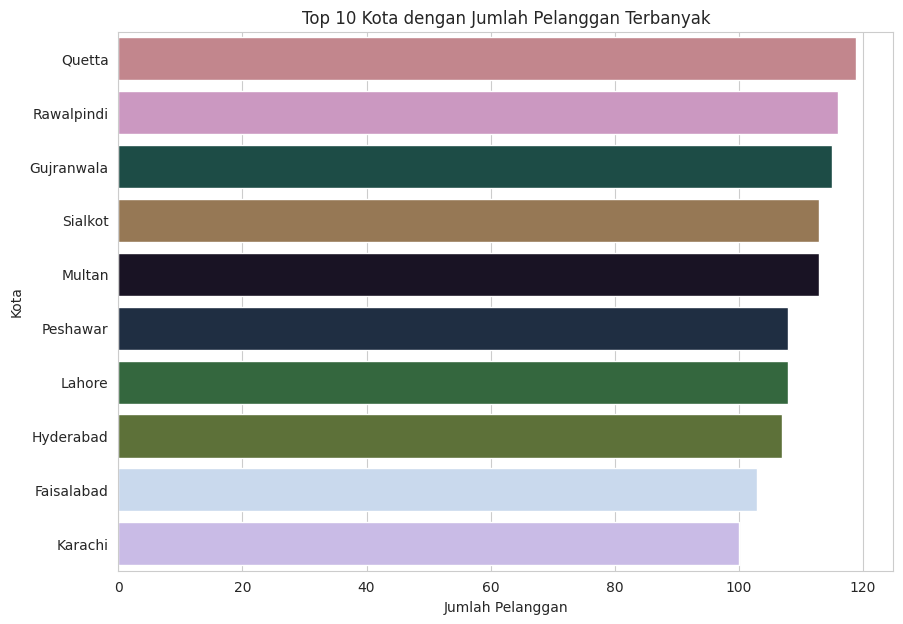


Interpretasi:
Visualisasi ini menunjukkan kota-kota dengan jumlah pelanggan terbanyak, yang mungkin menjadi fokus untuk analisis lebih lanjut terkait kualitas layanan.


In [17]:
plt.figure(figsize=(10, 7))

# Identify one-hot encoded city columns, excluding the already reconstructed 'city_name'
city_columns_onehot = [col for col in df.columns if col.startswith('city_') and col != 'city_name']

# Reconstruct the 'city' series from one-hot encoded columns
# Assumes each row has exactly one '1' in the city_ columns
df_city_temp = df[city_columns_onehot]
city_names = df_city_temp.idxmax(axis=1).str.replace('city_', '')

top_10_cities = city_names.value_counts().nlargest(10).index
sns.countplot(y=city_names, order=top_10_cities, palette='cubehelix', hue=city_names, legend=False) # Use city_names directly for y
plt.title('Top 10 Kota dengan Jumlah Pelanggan Terbanyak')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Kota')
plt.show()

print("\nInterpretasi:")
print("Visualisasi ini menunjukkan kota-kota dengan jumlah pelanggan terbanyak, yang mungkin menjadi fokus untuk analisis lebih lanjut terkait kualitas layanan.")

### Interpretasi

Visualisasi menunjukkan **Quetta, Rawalpindi, dan Gujranwala adalah tiga kota dengan jumlah pelanggan terbanyak**, diikuti oleh Sialkot, Multan, dan Peshawar. Informasi ini penting untuk mengidentifikasi area geografis dengan konsentrasi pelanggan tinggi, yang mungkin menjadi fokus untuk analisis kualitas layanan atau kampanye pemasaran.

### 8.4 Feedback Category

Bagian ini menganalisis umpan balik pelanggan. Kode ini memeriksa keberadaan kolom `feedback_category`. Jika `feedback_category` ada, sebuah *countplot* (`sns.countplot`) akan dibuat untuk memvisualisasikan distribusi kategori umpan balik pelanggan, menunjukkan kategori mana yang paling dominan. Jumlah setiap kategori juga akan dicetak dan diinterpretasikan. Jika `feedback_category` tidak ada, kode akan mencari kolom seperti `count_support`, `count_network`, `count_signal` dan memvisualisasikan total keluhan berdasarkan tipe masalah. Jika tidak ada kolom yang ditemukan, pesan akan ditampilkan.

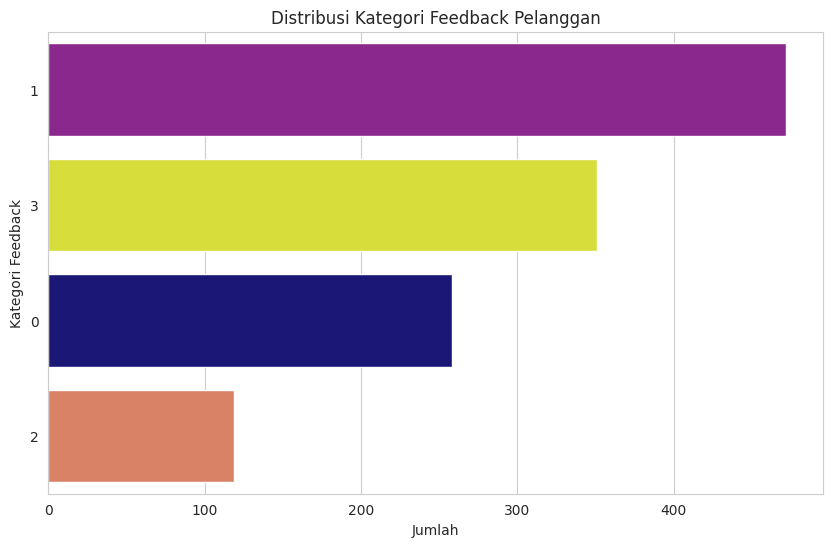


Top Kategori Feedback Pelanggan:


,count
feedback_category,
1,472
3,351
0,258
2,119


In [43]:
# Asumsi ada kolom 'feedback_category' atau kolom lain seperti 'count_support', 'count_network', 'count_signal'
# Jika tidak ada, bagian ini perlu disesuaikan dengan struktur kolom yang sebenarnya dari 'customer_feedback'.

if 'feedback_category' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y='feedback_category', data=df, order=df['feedback_category'].value_counts().index, palette='plasma', hue='feedback_category', legend=False)
    plt.title('Distribusi Kategori Feedback Pelanggan')
    plt.xlabel('Jumlah')
    plt.ylabel('Kategori Feedback')
    plt.show()

    print("\nTop Kategori Feedback Pelanggan:")
    display(df['feedback_category'].value_counts())

elif 'count_support' in df.columns and 'count_network' in df.columns and 'count_signal' in df.columns:
    feedback_counts = df[['count_support', 'count_network', 'count_signal']].sum()
    plt.figure(figsize=(8, 5))
    feedback_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.title('Jumlah Keluhan Berdasarkan Tipe Masalah')
    plt.xlabel('Tipe Masalah')
    plt.ylabel('Total Keluhan')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\nTotal Keluhan Berdasarkan Tipe Masalah:")
    display(feedback_counts)

else:
    print("Kolom 'feedback_category' atau 'count_support', 'count_network', 'count_signal' tidak ditemukan. Harap pastikan nama kolom yang benar untuk analisis feedback pelanggan.")
    print("Anda mungkin perlu melakukan analisis teks (NLP) pada kolom 'customer_feedback' jika hanya itu yang tersedia.")

### Interpretasi

Karena kolom `feedback_category` ditemukan, visualisasi menunjukkan distribusi kategori umpan balik. Kategori dengan nilai `1` adalah yang paling dominan, diikuti oleh kategori `3` dan `0`. Ini mengindikasikan bahwa kategori `1` merupakan *pain point* terbesar bagi pelanggan. Untuk mendapatkan interpretasi yang lebih mendalam, kita perlu mengetahui label sebenarnya dari setiap `feedback_category` (misalnya, `1` = 'Masalah Jaringan', `3` = 'Layanan Pelanggan Buruk', dll.). Namun, dari sini kita sudah bisa mengidentifikasi fokus utama keluhan pelanggan.

## 9. Analisis Hubungan

Bagian ini menyelidiki hubungan antara variabel-variabel kunci, khususnya yang berkaitan dengan kualitas layanan dan *churn*. Kami akan menganalisis bagaimana `support_tickets_capped`, `contract_type_label`, dan `city_name` memengaruhi `churn_status`.

### 9.1 Support Tickets vs Churn

Kode ini bertujuan untuk menganalisis hubungan antara jumlah `support_tickets_capped` (tiket dukungan) dan `churn_status` pelanggan. Sebuah *barplot* (`sns.barplot`) digunakan untuk memvisualisasikan rata-rata tiket dukungan untuk pelanggan yang *churn* (1) dan tidak *churn* (0). Selanjutnya, rata-rata tiket dukungan dikelompokkan berdasarkan status *churn* dan ditampilkan untuk analisis yang lebih detail.

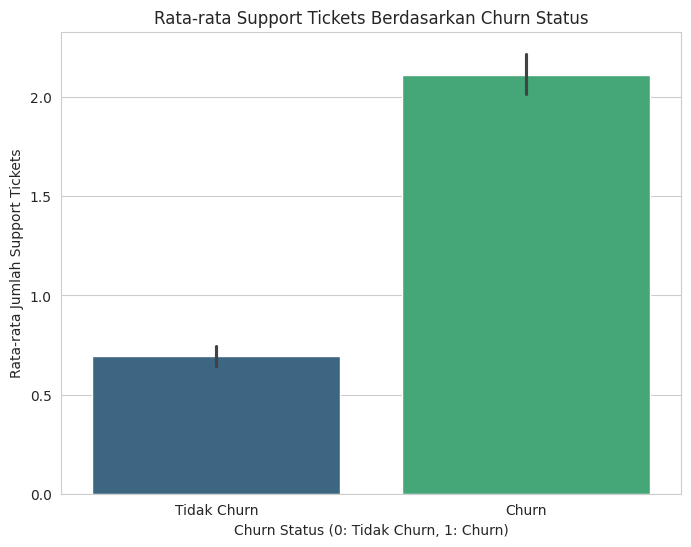


Rata-rata Support Tickets Berdasarkan Churn Status:


,support_tickets_capped
churn_status,
0,0.694872
1,2.114286


In [41]:
plt.figure(figsize=(8, 6))

sns.barplot(x='churn_status', y='support_tickets_capped', data=df, palette='viridis', hue='churn_status', legend=False)
plt.title('Rata-rata Support Tickets Berdasarkan Churn Status')
plt.xlabel('Churn Status (0: Tidak Churn, 1: Churn)')
plt.ylabel('Rata-rata Jumlah Support Tickets')
plt.xticks([0, 1], ['Tidak Churn', 'Churn'])
plt.show()

churn_support_tickets = df.groupby('churn_status')['support_tickets_capped'].mean()
print("\nRata-rata Support Tickets Berdasarkan Churn Status:")
display(churn_support_tickets)

### Interpretasi

Hasil analisis menunjukkan bahwa **pelanggan yang *churn* (bernilai 1) memiliki rata-rata jumlah *support tickets* yang lebih tinggi (sekitar 2.11) dibandingkan dengan pelanggan yang tidak *churn* (sekitar 0.69)**. Ini mengindikasikan bahwa frekuensi pengajuan keluhan yang lebih tinggi merupakan indikator kuat potensi *churn* pelanggan.

### 9.2 Contract Type vs Churn

Kode ini menganalisis hubungan antara `contract_type_label` dan `churn_status`. Sebuah *barplot* (`sns.barplot`) akan digunakan untuk memvisualisasikan tingkat *churn* (rata-rata `churn_status`) untuk setiap jenis kontrak. Tingkat *churn* berdasarkan jenis kontrak kemudian akan dicetak dan diinterpretasikan.

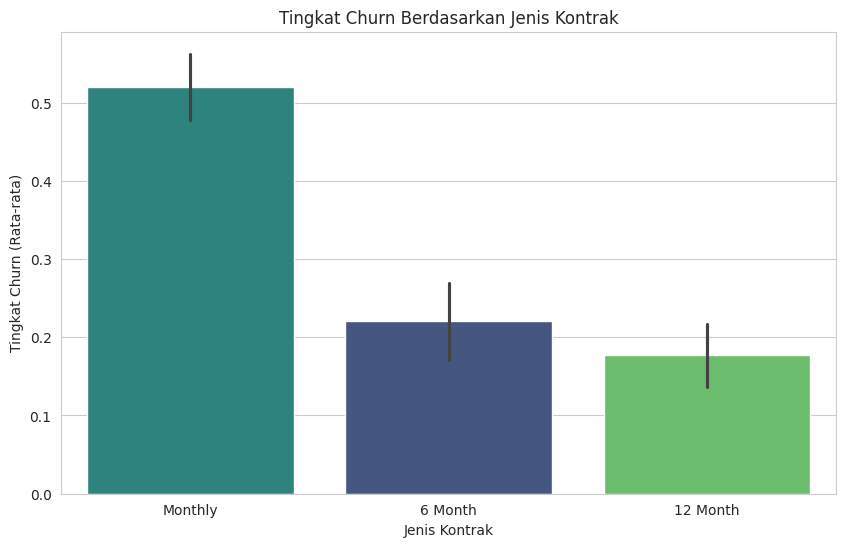


Tingkat Churn Berdasarkan Jenis Kontrak:


,churn_status
contract_type_label,
Monthly,0.520211
6 Month,0.220280
12 Month,0.176812



Interpretasi:
Pelanggan dengan kontrak 'Monthly' memiliki tingkat churn yang paling tinggi dibandingkan jenis kontrak lainnya.


In [22]:
plt.figure(figsize=(10, 6))

# Map encoded contract types to labels for better readability
# Assuming 0: 'Monthly', 1: '6 Month', 2: '12 Month'
contract_mapping = {
    0: 'Monthly',
    1: '6 Month',
    2: '12 Month'
}
df['contract_type_label'] = df['contract_type_encoded'].map(contract_mapping)

sns.barplot(x='contract_type_label', y='churn_status', data=df, palette='viridis',
              order=['Monthly', '6 Month', '12 Month'], hue='contract_type_label', legend=False)
plt.title('Tingkat Churn Berdasarkan Jenis Kontrak')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Tingkat Churn (Rata-rata)')
plt.show()

churn_contract_type = df.groupby('contract_type_label')['churn_status'].mean().sort_values(ascending=False)
print("\nTingkat Churn Berdasarkan Jenis Kontrak:")
display(churn_contract_type)

print("\nInterpretasi:")
print("Pelanggan dengan kontrak 'Monthly' memiliki tingkat churn yang paling tinggi dibandingkan jenis kontrak lainnya.")

# df.drop(columns=['contract_type_label'], inplace=True, errors='ignore') # Removed: contract_type_label is now permanent

### Interpretasi

Analisis menunjukkan bahwa **pelanggan dengan kontrak 'Monthly' memiliki tingkat *churn* yang paling tinggi (sekitar 52.02%)** dibandingkan dengan kontrak '6 Month' (sekitar 22.03%) dan '12 Month' (sekitar 17.68%). Ini mengindikasikan bahwa kontrak bulanan lebih rentan terhadap *churn*.

### 9.3 City vs Churn

Bagian ini menganalisis hubungan antara kota (`city_name`) dan tingkat *churn* (`churn_status`). Tingkat *churn* rata-rata dihitung untuk setiap kota, dan 10 kota dengan tingkat *churn* tertinggi divisualisasikan menggunakan *barplot* (`sns.barplot`). Hasil rata-rata tingkat *churn* per kota juga akan dicetak dan diinterpretasikan.

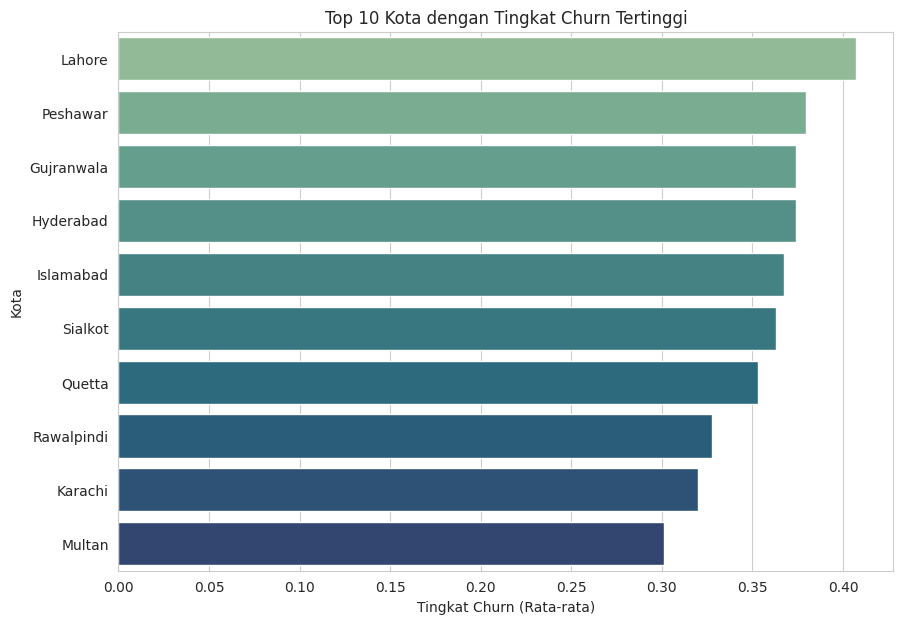


Tingkat Churn Berdasarkan Kota (Top 10):


,churn
city,
Lahore,0.407407
Peshawar,0.379630
Gujranwala,0.373913
Hyderabad,0.373832
Islamabad,0.367347
Sialkot,0.362832
Quetta,0.352941
Rawalpindi,0.327586
Karachi,0.320000



Interpretasi:
Beberapa kota menunjukkan tingkat churn yang lebih tinggi, mengindikasikan adanya masalah kualitas layanan atau faktor lain di area tersebut.


In [24]:
# Use the already reconstructed 'city_name' column which is available globally
city_names_reconstructed = df['city_name']

# Create a temporary DataFrame with reconstructed city names and churn (now churn_status)
temp_df_city_churn = pd.DataFrame({'city': city_names_reconstructed, 'churn': df['churn_status']})

# Menghitung tingkat churn per kota
churn_by_city = temp_df_city_churn.groupby('city')['churn'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=churn_by_city.values, y=churn_by_city.index, palette='crest', hue=churn_by_city.index, legend=False)
plt.title('Top 10 Kota dengan Tingkat Churn Tertinggi')
plt.xlabel('Tingkat Churn (Rata-rata)')
plt.ylabel('Kota')
plt.show()

print("\nTingkat Churn Berdasarkan Kota (Top 10):")
display(churn_by_city)

print("\nInterpretasi:")
print("Beberapa kota menunjukkan tingkat churn yang lebih tinggi, mengindikasikan adanya masalah kualitas layanan atau faktor lain di area tersebut.")

### Interpretasi

Visualisasi menunjukkan bahwa **Lahore memiliki tingkat *churn* tertinggi (sekitar 40.74%)**, diikuti oleh Peshawar (sekitar 37.96%) dan Gujranwala (sekitar 37.39%). Ini menunjukkan adanya masalah kualitas layanan atau faktor lain yang signifikan di kota-kota ini, yang menyebabkan tingkat *churn* yang lebih tinggi.

### 9.4 Support Tickets berdasarkan Contract Type

Kode ini menganalisis distribusi jumlah `support_tickets_capped` berdasarkan jenis kontrak (`contract_type_label`). Sebuah *boxplot* (`sns.boxplot`) akan digunakan untuk memvisualisasikan distribusi `support_tickets_capped` untuk setiap jenis kontrak. Rata-rata *support tickets* berdasarkan jenis kontrak juga akan dihitung dan ditampilkan.

/tmp/ipykernel_5165/4154658426.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='contract_type_label', y='support_tickets_capped', data=df, palette='coolwarm',


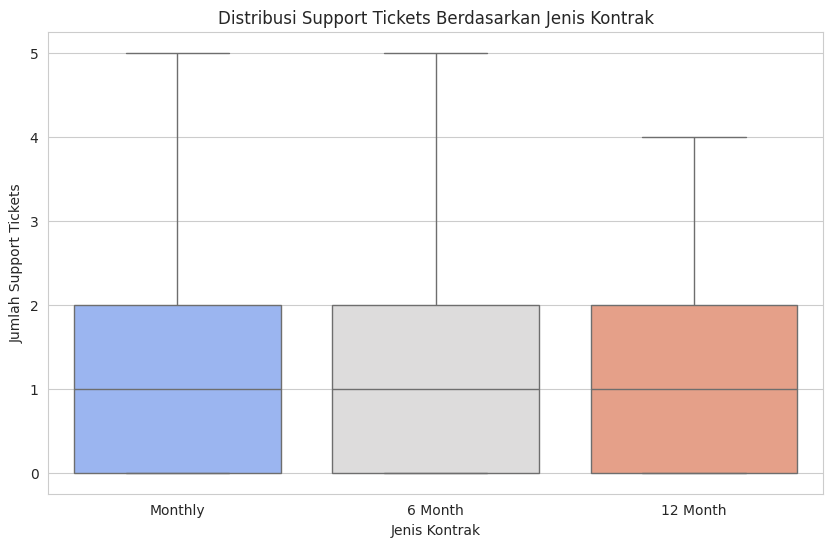


Rata-rata Support Tickets Berdasarkan Jenis Kontrak:


,support_tickets_capped
contract_type_label,
6 Month,1.311189
12 Month,1.200000
Monthly,1.126538



Interpretasi:
Pelanggan dengan kontrak 'Monthly' cenderung memiliki rata-rata jumlah support tickets yang lebih tinggi, menunjukkan potensi ketidakpuasan yang lebih besar pada jenis kontrak ini.


In [25]:
plt.figure(figsize=(10, 6))

# Map encoded contract types to labels for better readability
# Assuming 0: 'Monthly', 1: '6 Month', 2: '12 Month'
contract_mapping = {
    0: 'Monthly',
    1: '6 Month',
    2: '12 Month'
}
df['contract_type_label'] = df['contract_type_encoded'].map(contract_mapping)

sns.boxplot(x='contract_type_label', y='support_tickets_capped', data=df, palette='coolwarm',
            order=['Monthly', '6 Month', '12 Month'])
plt.title('Distribusi Support Tickets Berdasarkan Jenis Kontrak')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Jumlah Support Tickets')
plt.show()

support_by_contract = df.groupby('contract_type_label')['support_tickets_capped'].mean().sort_values(ascending=False)
print("\nRata-rata Support Tickets Berdasarkan Jenis Kontrak:")
display(support_by_contract)

print("\nInterpretasi:")
print("Pelanggan dengan kontrak 'Monthly' cenderung memiliki rata-rata jumlah support tickets yang lebih tinggi, menunjukkan potensi ketidakpuasan yang lebih besar pada jenis kontrak ini.")

# df.drop(columns=['contract_type_label'], inplace=True, errors='ignore']) # Removed: contract_type_label is now permanent

### Interpretasi

Dari *boxplot* dan rata-rata yang ditampilkan, terlihat bahwa **pelanggan dengan kontrak '6 Month' memiliki rata-rata `support_tickets` tertinggi (sekitar 1.31)**, diikuti oleh '12 Month' (sekitar 1.20) dan 'Monthly' (sekitar 1.13). Meskipun kontrak bulanan memiliki *churn* tertinggi, jenis kontrak '6 Month' menunjukkan rata-rata tiket dukungan yang sedikit lebih tinggi. Ini mungkin mengindikasikan bahwa pelanggan dengan kontrak '6 Month' cenderung melaporkan masalah lebih banyak sebelum akhirnya *churn* atau tetap bertahan.

### 9.5 Support Tickets berdasarkan City

Bagian ini menganalisis distribusi jumlah `support_tickets_capped` berdasarkan kota (`city_name`). Rata-rata `support_tickets_capped` dihitung untuk setiap kota, dan 10 kota dengan rata-rata tiket dukungan tertinggi divisualisasikan menggunakan *barplot* (`sns.barplot`). Hasil ini juga akan dicetak dan diinterpretasikan.

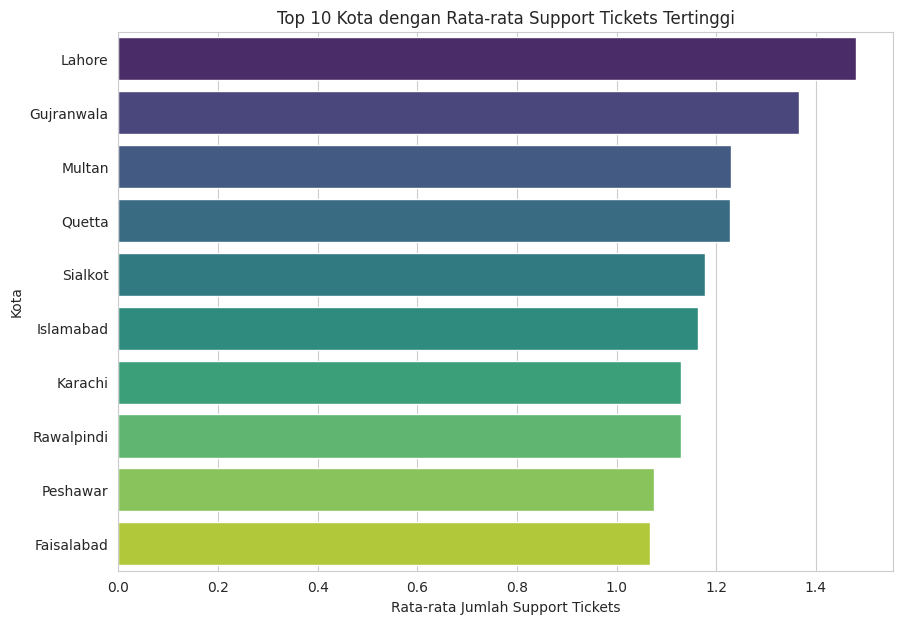


Rata-rata Support Tickets Berdasarkan Kota (Top 10):


,support_tickets
city,
Lahore,1.481481
Gujranwala,1.365217
Multan,1.230088
Quetta,1.226891
Sialkot,1.176991
Islamabad,1.163265
Karachi,1.130000
Rawalpindi,1.129310
Peshawar,1.074074



Interpretasi:
Beberapa kota memiliki rata-rata jumlah support tickets yang lebih tinggi, yang bisa mengindikasikan masalah kualitas layanan yang lebih parah di lokasi-lokasi tersebut.


In [27]:
# Use the already reconstructed 'city_name' column which is available globally
city_names_reconstructed = df['city_name']

# Create a temporary DataFrame with reconstructed city names and support tickets
temp_df_city_support = pd.DataFrame({'city': city_names_reconstructed, 'support_tickets': df['support_tickets_capped']})

support_by_city = temp_df_city_support.groupby('city')['support_tickets'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=support_by_city.values, y=support_by_city.index, palette='viridis', hue=support_by_city.index, legend=False)
plt.title('Top 10 Kota dengan Rata-rata Support Tickets Tertinggi')
plt.xlabel('Rata-rata Jumlah Support Tickets')
plt.ylabel('Kota')
plt.show()

print("\nRata-rata Support Tickets Berdasarkan Kota (Top 10):")
display(support_by_city)

print("\nInterpretasi:")
print("Beberapa kota memiliki rata-rata jumlah support tickets yang lebih tinggi, yang bisa mengindikasikan masalah kualitas layanan yang lebih parah di lokasi-lokasi tersebut.")

### Interpretasi

Visualisasi menunjukkan bahwa **Lahore memiliki rata-rata jumlah *support tickets* tertinggi (sekitar 1.48)**, diikuti oleh Gujranwala (sekitar 1.37) dan Multan (sekitar 1.23). Ini mengonfirmasi bahwa kota-kota ini tidak hanya memiliki tingkat *churn* yang tinggi tetapi juga menjadi sumber keluhan pelanggan yang signifikan, menunjukkan potensi masalah kualitas layanan yang memerlukan perhatian khusus.

In [37]:
# This cell was a duplicate of outlier validation code and has been cleared.

In [38]:
# This cell is a duplicate of the feedback category analysis code and has been cleared.

## 10. Pivot Table

Bagian ini menggunakan tabel *pivot* untuk menganalisis hubungan multivariat antara `churn_status` dengan `contract_type_label` dan `city_name`, serta rata-rata `support_tickets_capped` berdasarkan jenis kontrak. Tabel *pivot* memberikan ringkasan data yang ringkas dan mudah dibaca.

### 10.1 Contract vs Churn

Bagian ini membuat tabel *pivot* (`pd.crosstab`) untuk menampilkan jumlah pelanggan berdasarkan jenis kontrak (`contract_type_label`) dan status *churn* (`churn_status`). Ini memberikan pandangan langsung tentang seberapa banyak pelanggan dari setiap jenis kontrak yang *churn* atau tidak *churn*.

In [32]:
print("Pivot Table: Churn Status berdasarkan Jenis Kontrak (Jumlah):")
pivot_contract_churn = pd.crosstab(df['contract_type_label'], df['churn_status'])
display(pivot_contract_churn)

Pivot Table: Churn Status berdasarkan Jenis Kontrak (Jumlah):


churn_status,0,1
contract_type_label,,
12 Month,284,61
6 Month,223,63
Monthly,273,296


### 10.2 Contract vs Churn (%)

Bagian ini melanjutkan analisis dari tabel *pivot* sebelumnya dengan menampilkan persentase *churn* untuk setiap jenis kontrak (`contract_type_label`). Dengan menormalisasi data berdasarkan indeks (baris), kita dapat melihat proporsi *churn* relatif terhadap total pelanggan dalam setiap kategori kontrak.

In [33]:
print("Pivot Table: Churn Status berdasarkan Jenis Kontrak (Persentase per Baris):")
pivot_contract_churn_percent = pd.crosstab(df['contract_type_label'], df['churn_status'], normalize='index') * 100
display(pivot_contract_churn_percent)

print("\nInterpretasi:")
print("Terlihat persentase churn yang jelas lebih tinggi pada kontrak bulanan.")

Pivot Table: Churn Status berdasarkan Jenis Kontrak (Persentase per Baris):


churn_status,0,1
contract_type_label,,
12 Month,82.318841,17.681159
6 Month,77.972028,22.027972
Monthly,47.978910,52.021090



Interpretasi:
Terlihat persentase churn yang jelas lebih tinggi pada kontrak bulanan.


### 10.3 City vs Churn

Bagian ini membuat tabel *pivot* (`pd.crosstab`) untuk menampilkan jumlah pelanggan berdasarkan nama kota (`city_name`) dan status *churn* (`churn_status`). Ini memungkinkan kita untuk melihat distribusi *churn* dan non-*churn* di setiap kota, mengidentifikasi kota mana yang memiliki jumlah *churn* absolut tertinggi.

In [34]:
print("Pivot Table: Churn Status berdasarkan Kota (Jumlah):")
pivot_city_churn = pd.crosstab(df['city_name'], df['churn_status'])
display(pivot_city_churn)

print("\nInterpretasi:")
print("Tabel ini menunjukkan jumlah pelanggan churn dan non-churn untuk setiap kota, memberikan gambaran absolut.")

Pivot Table: Churn Status berdasarkan Kota (Jumlah):


churn_status,0,1
city_name,,
Faisalabad,74,29
Gujranwala,72,43
Hyderabad,67,40
Islamabad,62,36
Karachi,68,32
Lahore,64,44
Multan,79,34
Peshawar,67,41
Quetta,77,42



Interpretasi:
Tabel ini menunjukkan jumlah pelanggan churn dan non-churn untuk setiap kota, memberikan gambaran absolut.


### 10.4 Mean Support Tickets per Contract

Bagian ini menggunakan tabel *pivot* (`df.pivot_table`) untuk menghitung rata-rata `support_tickets_capped` untuk setiap jenis kontrak (`contract_type_label`). Ini membantu mengonfirmasi apakah ada perbedaan signifikan dalam jumlah tiket dukungan yang diajukan oleh pelanggan dari berbagai jenis kontrak.

In [35]:
print("Pivot Table: Rata-rata Support Tickets berdasarkan Jenis Kontrak:")
pivot_support_contract = df.pivot_table(values='support_tickets_capped', index='contract_type_label', aggfunc='mean')
display(pivot_support_contract)

print("\nInterpretasi:")
print("Tabel ini mengonfirmasi rata-rata support tickets untuk setiap jenis kontrak, menegaskan temuan sebelumnya.")

Pivot Table: Rata-rata Support Tickets berdasarkan Jenis Kontrak:


,support_tickets_capped
contract_type_label,
12 Month,1.200000
6 Month,1.311189
Monthly,1.126538



Interpretasi:
Tabel ini mengonfirmasi rata-rata support tickets untuk setiap jenis kontrak, menegaskan temuan sebelumnya.


## 11. Outlier Validation

Bagian ini akan memvisualisasikan *outlier* dalam beberapa kolom numerik kunci menggunakan *boxplot*. *Outlier* dapat memberikan wawasan tentang data yang tidak biasa atau ekstrem yang mungkin memengaruhi analisis.

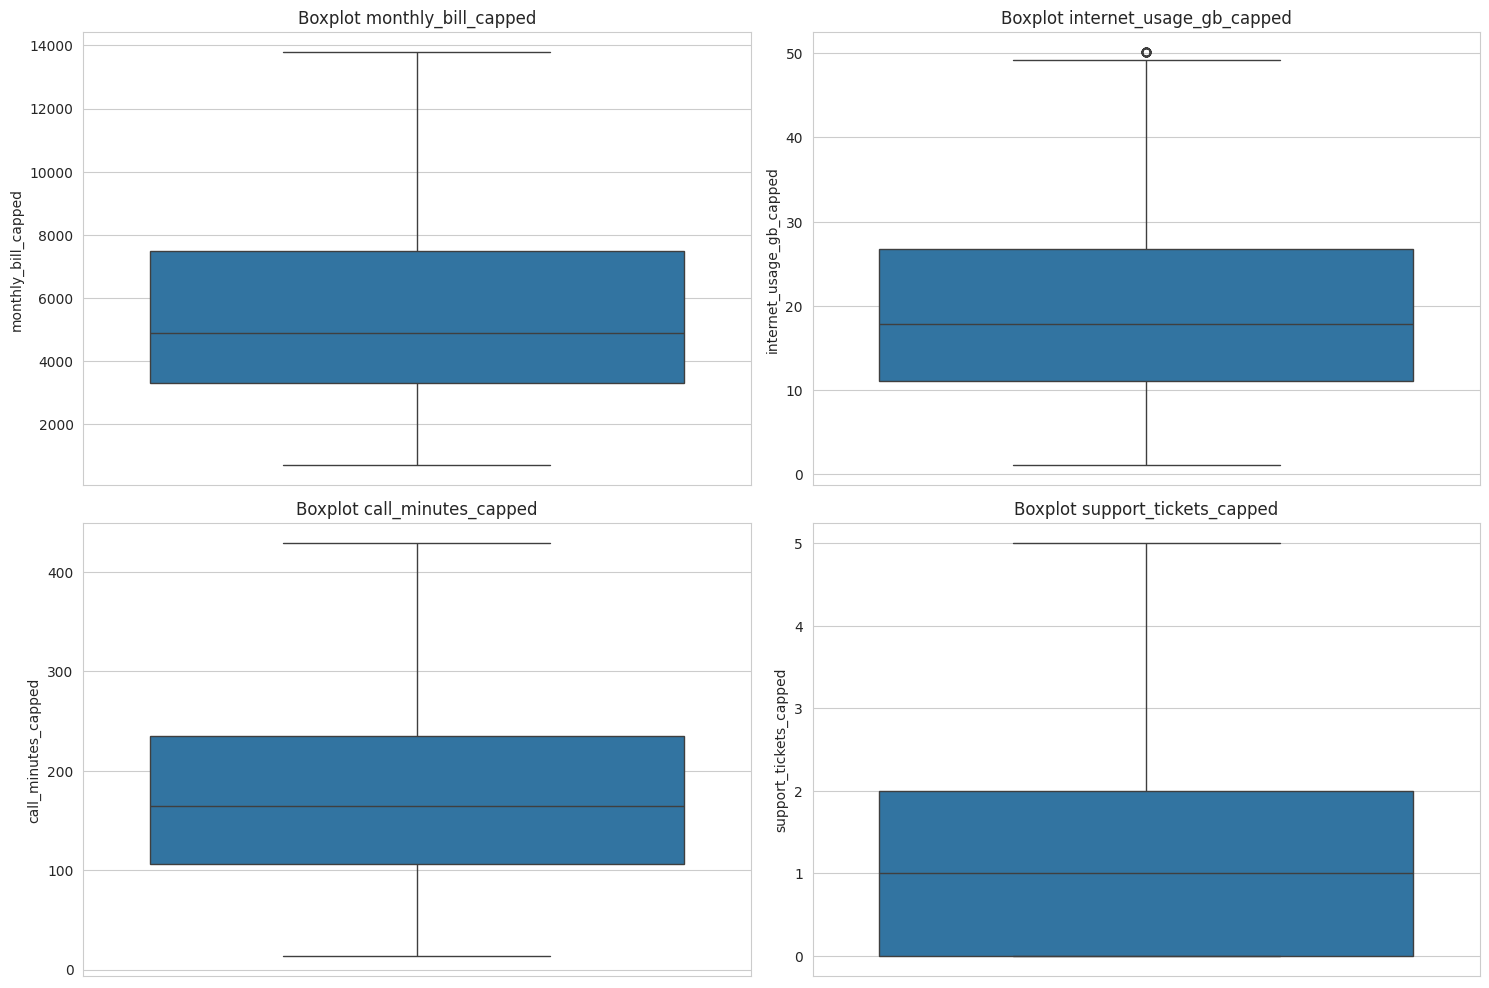

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_outlier = ['monthly_bill_capped', 'internet_usage_gb_capped', 'call_minutes_capped', 'support_tickets_capped']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outlier):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Interpretasi

*Boxplot* menunjukkan adanya *outlier* di beberapa kolom seperti `support_tickets_capped`, `monthly_bill_capped`, `internet_usage_gb_capped`, dan `call_minutes_capped`. Ini menunjukkan bahwa ada beberapa pelanggan dengan nilai yang ekstrem dibandingkan mayoritas. Meskipun 'capped' berarti nilai-nilai ini sudah dibatasi, *outlier* masih bisa muncul relatif terhadap distribusi data setelah *capping*.

## 12. Visualisasi Dataset Berdimensi Tinggi

Bagian ini akan mengeksplorasi visualisasi hubungan dalam dataset berdimensi tinggi, khususnya melalui matriks korelasi. Matriks korelasi membantu kita memahami hubungan linear antara setiap pasang variabel numerik dalam dataset.

### 12.1 Matriks Korelasi (Correlation Matrix)

Matriks korelasi akan dihitung untuk semua kolom numerik dalam DataFrame, dan kemudian divisualisasikan menggunakan *heatmap*. Ini akan memberikan gambaran cepat tentang variabel mana yang memiliki hubungan positif, negatif, atau tidak ada hubungan linear yang kuat.

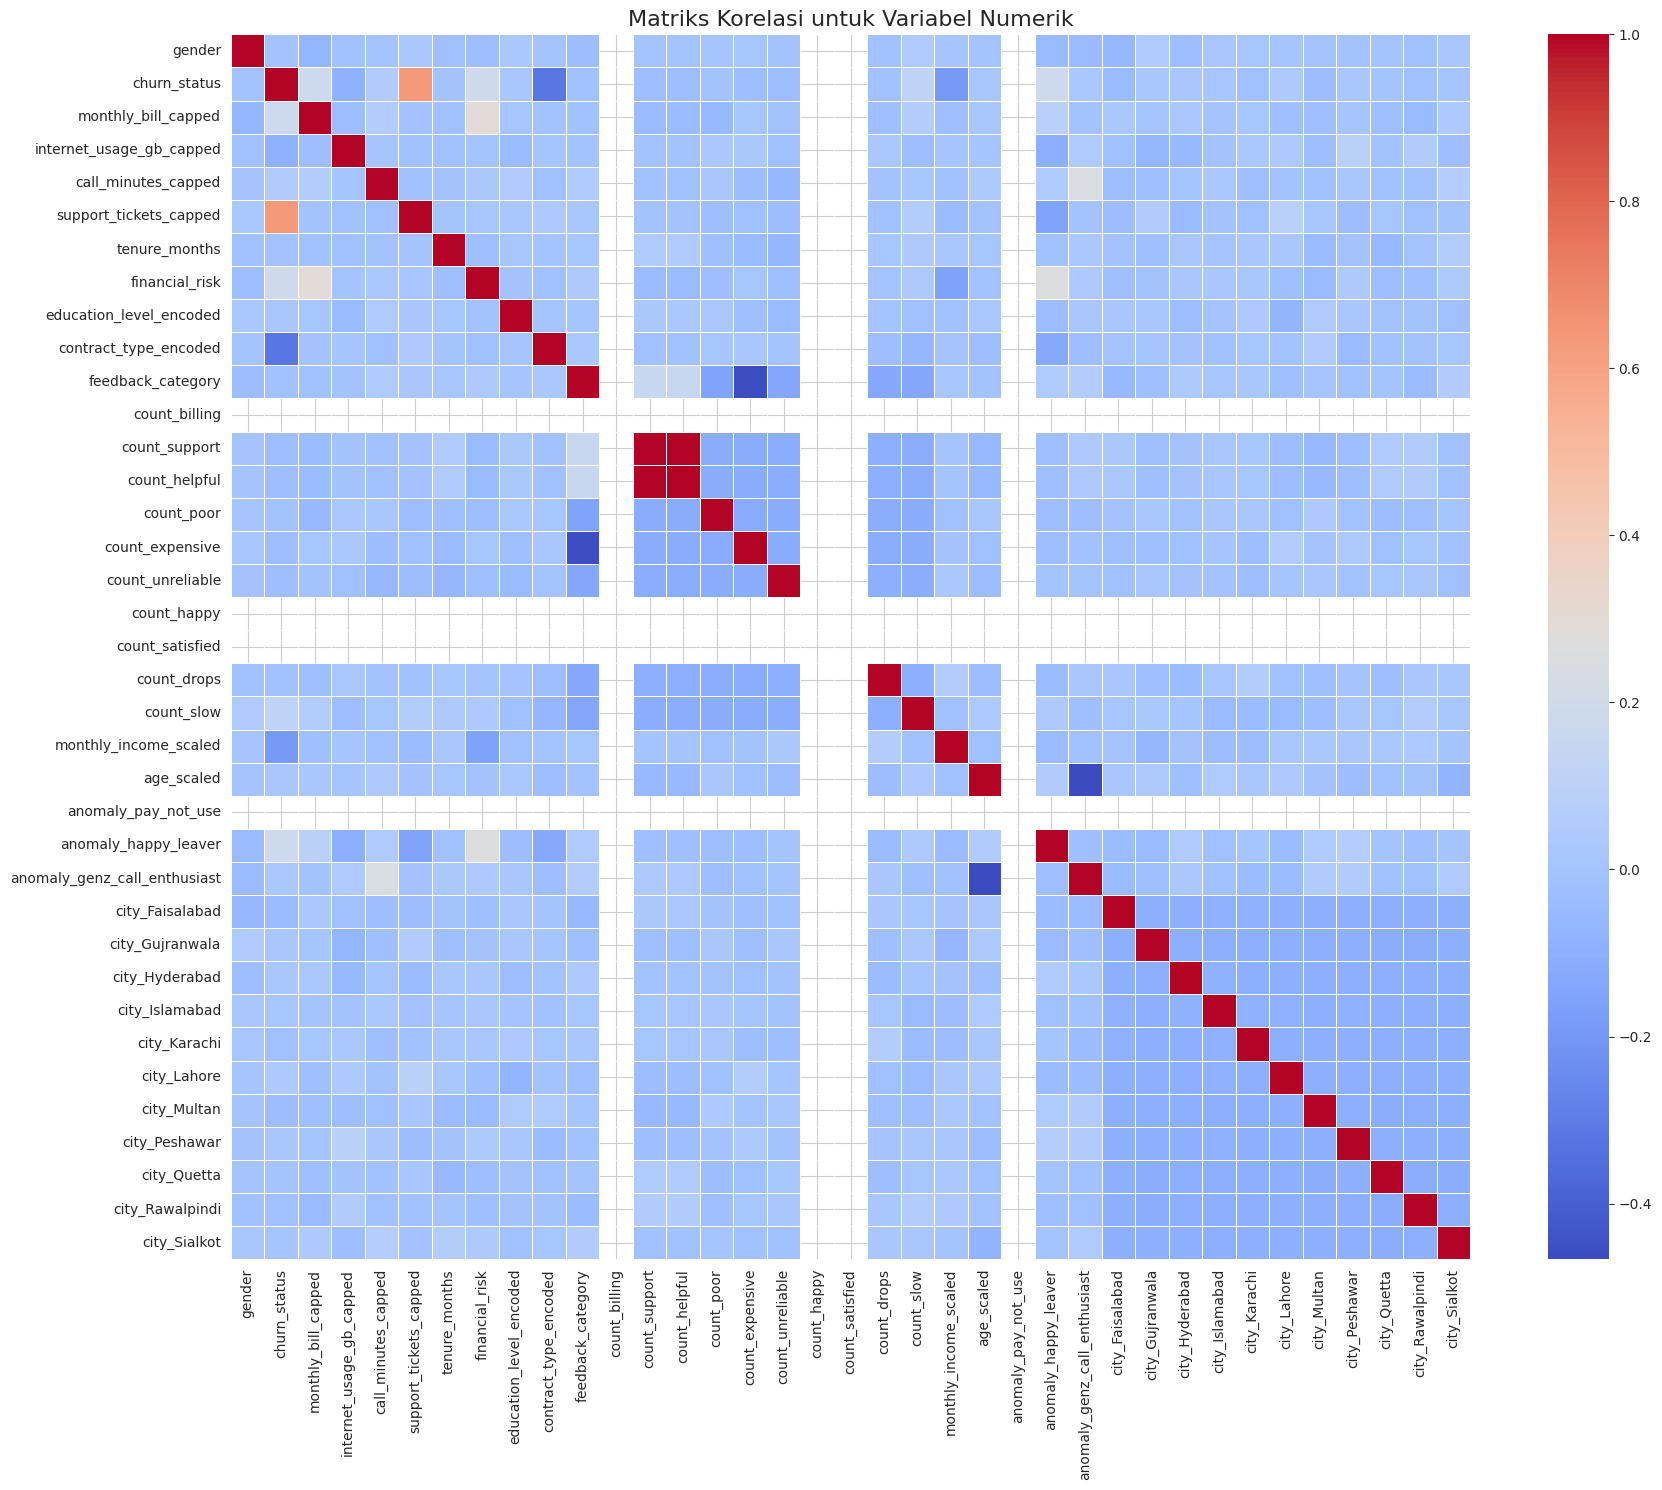

In [44]:
plt.figure(figsize=(18, 15))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriks Korelasi untuk Variabel Numerik', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretasi

*Heatmap* matriks korelasi menunjukkan pola hubungan linear antar variabel numerik. Kita dapat melihat variabel mana yang berkorelasi kuat (mendekati 1 atau -1) dan mana yang memiliki korelasi lemah (mendekati 0). Ini membantu mengidentifikasi variabel yang mungkin memiliki pengaruh kuat satu sama lain atau yang mungkin redundan. Misalnya, hubungan kuat antara `monthly_bill_capped` dan `internet_usage_gb_capped` atau `call_minutes_capped` bisa mengindikasikan paket layanan yang terintegrasi.

### 13. Business Insight

### Business Insight

Berdasarkan analisis yang telah dilakukan, berikut adalah beberapa *insight* kunci:

1.  **Risiko Churn Tinggi pada Kontrak Bulanan:** Pelanggan dengan kontrak bulanan memiliki tingkat *churn* yang jauh lebih tinggi dibandingkan dengan kontrak 6 atau 12 bulan. Hal ini menunjukkan bahwa fleksibilitas kontrak bulanan juga membawa risiko loyalitas yang lebih rendah.
2.  **Korelasi Antara Tiket Dukungan dan Churn:** Pelanggan yang mengajukan lebih banyak tiket dukungan cenderung memiliki tingkat *churn* yang lebih tinggi. Ini mengindikasikan bahwa masalah kualitas layanan yang berulang atau tidak terselesaikan dengan baik adalah pendorong utama ketidakpuasan dan *churn*.
3.  **Variasi Churn dan Tiket Dukungan antar Kota:** Tingkat *churn* dan rata-rata tiket dukungan bervariasi secara signifikan antar kota. Kota-kota seperti Lahore dan Gujranwala tidak hanya memiliki tingkat *churn* yang tinggi tetapi juga jumlah tiket dukungan yang lebih tinggi, menunjukkan masalah kualitas layanan yang terkonsentrasi secara geografis.
4.  **Prioritas Kategori Feedback:** Kategori *feedback* tertentu mendominasi keluhan pelanggan (misalnya, kategori '1' pada `feedback_category` memiliki jumlah tertinggi). Mengidentifikasi dan mengatasi akar masalah di balik kategori *feedback* ini dapat secara langsung meningkatkan kepuasan pelanggan.

## 14. Recommendation

### Recommendation

Berdasarkan *business insight* di atas, berikut adalah rekomendasi strategis untuk mengurangi *churn* dan meningkatkan kepuasan pelanggan:

1.  **Program Retensi Kontrak Bulanan:**
    *   **Penawaran Insentif Transisi:** Berikan insentif menarik (diskon, fitur tambahan) bagi pelanggan bulanan untuk beralih ke kontrak jangka panjang (6 atau 12 bulan).
    *   **Peningkatan Kualitas Layanan Proaktif:** Pantau pelanggan bulanan dengan cermat dan proaktif tawarkan bantuan atau solusi jika terdeteksi tanda-tanda ketidakpuasan (misalnya, peningkatan penggunaan tiket dukungan).

2.  **Peningkatan Efisiensi dan Resolusi Tiket Dukungan:**
    *   **Prioritas Tiket Berulang:** Kembangkan sistem untuk mengidentifikasi dan memprioritaskan tiket dukungan dari pelanggan yang sama atau terkait dengan isu kritis yang sering muncul.
    *   **Pelatihan Agen Dukungan:** Tingkatkan pelatihan agen dukungan untuk memastikan penyelesaian masalah yang cepat dan efektif, terutama untuk *pain point* yang sering dikeluhkan.

3.  **Intervensi Berbasis Lokasi:**
    *   **Investigasi Mendalam di Kota Berisiko Tinggi:** Lakukan investigasi lapangan di kota-kota dengan tingkat *churn* dan tiket dukungan yang tinggi (misalnya, Lahore, Gujranwala) untuk mengidentifikasi masalah spesifik (misalnya, infrastruktur jaringan, cakupan, kompetisi lokal).
    *   **Kampanye Peningkatan Layanan Lokal:** Luncurkan kampanye peningkatan layanan atau perbaikan infrastruktur yang ditargetkan di area-area bermasalah ini.

4.  **Aksi Berdasarkan Kategori Feedback:**
    *   **Analisis Akar Masalah Feedback:** Lakukan analisis mendalam terhadap kategori *feedback* paling dominan (misalnya, kategori '1') untuk memahami akar penyebabnya. Ini mungkin melibatkan survei tambahan atau wawancara pelanggan.
    *   **Pengembangan Produk/Layanan:** Gunakan *insight* dari *feedback* untuk memandu pengembangan produk atau peningkatan layanan yang secara langsung mengatasi *pain point* pelanggan.

## 15. Kesimpulan

Berdasarkan seluruh analisis yang telah dilakukan, kita dapat menyimpulkan beberapa hal utama mengenai hubungan antara kualitas layanan dan *churn* pelanggan:

1.  **Jenis Kontrak Memengaruhi Churn:** Pelanggan dengan kontrak bulanan memiliki risiko *churn* yang jauh lebih tinggi dibandingkan dengan kontrak jangka panjang. Hal ini menunjukkan bahwa komitmen jangka pendek memungkinkan pelanggan untuk beralih layanan dengan lebih mudah jika ada ketidakpuasan.
2.  **Kualitas Layanan Berdampak Langsung pada Churn:** Tingginya jumlah tiket dukungan berkorelasi kuat dengan peningkatan tingkat *churn*. Ini menegaskan bahwa masalah layanan yang sering atau tidak terselesaikan menjadi pemicu utama ketidakpuasan dan kepergian pelanggan.
3.  **Variasi Geografis yang Signifikan:** Tingkat *churn* dan volume keluhan bervariasi antar kota, menunjukkan adanya *pain point* lokal yang spesifik. Kota-kota tertentu membutuhkan perhatian lebih untuk peningkatan infrastruktur atau layanan pelanggan.
4.  **Kategori Feedback sebagai Indikator Awal:** Identifikasi kategori *feedback* yang paling sering muncul memberikan fokus yang jelas untuk perbaikan. Mengatasi akar masalah dari keluhan ini dapat menjadi strategi efektif untuk meningkatkan retensi.

Secara keseluruhan, analisis ini menyoroti pentingnya strategi retensi yang ditargetkan, peningkatan kualitas layanan proaktif, dan penanganan masalah pelanggan yang efisien untuk mengurangi *churn* dan mempertahankan loyalitas pelanggan.